# GenRec Hint Cascade Deep Analysis

这份 notebook 面向远端服务器上的 `Instruments-grec` 结果，重点不是重复解释 cascade 指标，而是围绕下面几件事做结构化分析：

1. `task1_sid_sft` 和 `task4_hisTitle2sid` 到底谁更依赖 hint。
2. 需要更深 hint 的样本，是否对应更低频的 SID token。
3. 需要更深 hint 的样本，是否落在更小、更偏、更不平衡的局部 SID subtree。
4. 哪些 token / prefix 在 deep-hint 和 residual hard case 里过度集中。
5. 对交互序列类 task 来说，sequence 位置和 history 长度是否也在起作用。

所有 plot 的 title / label 都统一用英文，避免字体问题；中文说明放在 markdown 里。

## Notebook Roadmap

建议按下面顺序读：

1. `Beam-level overview`：先确认整体 cascade 形状。
2. `Task difficulty`：看 `sid` 和 `hisTitle2sid` 的 hint 强度差异。
3. `Tree / token feature build`：把每个样本映射到 token frequency 和 subtree statistics。
4. `Branch concentration`：直接找出 deep-hint / unsolved 样本堆积在哪些 token / prefix。
5. `Frequency vs subtree interaction`：看低频和小子树谁更主导，还是两者叠加。
6. `Sequence view`：只在 sequence-derived task 上补充解释。
7. `Export and narrative`：导出样本级综合表，并生成自动摘要。

口径约定：

- `effective_hint_depth = 0`：`base` 就命中。
- `effective_hint_depth = k`：最早在 `hint_k` 命中。
- `effective_hint_depth = max_hint_depth + 1`：跑到最后仍未命中。

In [1]:
from __future__ import annotations

import json
import math
import re
from collections import Counter, defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

plt.style.use('default')
pd.set_option('display.max_rows', 200)
pd.set_option('display.max_columns', 200)

SID_TOKEN_PATTERN = re.compile(r'<[^<>]+>')
TASK_LABELS = {
    'task1_sid_sft': 'sid',
    'task4_hisTitle2sid': 'hisTitle2sid',
    'task5_title_desc2sid': 'title_desc2sid',
}
TASK_ORDER = ['sid', 'hisTitle2sid', 'title_desc2sid']

In [2]:
REMOTE_REPO_ROOT = Path('/mnt/dolphinfs/hdd_pool/docker/user/hadoop-hmart-poistar/fanghaotian/GenRec')
REMOTE_DATA_ROOT = Path('/mnt/dolphinfs/hdd_pool/docker/user/hadoop-hmart-poistar/fanghaotian/data')
CATEGORY = 'Instruments'
DATA_VARIANT = 'Instruments_grec_index_emb-qwen3-embedding-4B_rq4_cb256-256-256-256_dsInstruments_ridFeb-10-2026-05-40-47'

ANALYSIS_SUMMARY_PATH = REMOTE_REPO_ROOT / 'temp/rl_beam_hint/instruments_grec_beam_hint_cascade_20260314_summary.json'
ANALYSIS_DETAILS_PATH = REMOTE_REPO_ROOT / 'temp/rl_beam_hint/instruments_grec_beam_hint_cascade_20260314_details.json'
VARIANT_ROOT = REMOTE_REPO_ROOT / 'data' / DATA_VARIANT
TRAIN_JSON_PATH = VARIANT_ROOT / 'rl/train.json'
INDEX_PATH = VARIANT_ROOT / 'id2sid.json'
ITEM_PATH = REMOTE_DATA_ROOT / CATEGORY / f'{CATEGORY}.item.json'
INTER_JSON_PATH = REMOTE_DATA_ROOT / CATEGORY / f'{CATEGORY}.inter.json'

FOCUS_BEAM_SIZE = 16
HISTORY_MAX = 50
EXPORT_DIR = REMOTE_REPO_ROOT / 'output/jupyter-notebook/genrec-hint-cascade-artifacts'

required_paths = [
    ANALYSIS_SUMMARY_PATH,
    ANALYSIS_DETAILS_PATH,
    TRAIN_JSON_PATH,
    INDEX_PATH,
    ITEM_PATH,
    INTER_JSON_PATH,
]

pd.DataFrame({'path': [str(path) for path in required_paths], 'exists': [path.exists() for path in required_paths]})

,path,exists
0,/mnt/dolphinfs/hdd_pool/docker/user/hadoop-hma...,True
1,/mnt/dolphinfs/hdd_pool/docker/user/hadoop-hma...,True
2,/mnt/dolphinfs/hdd_pool/docker/user/hadoop-hma...,True
3,/mnt/dolphinfs/hdd_pool/docker/user/hadoop-hma...,True
4,/mnt/dolphinfs/hdd_pool/docker/user/hadoop-hma...,True
5,/mnt/dolphinfs/hdd_pool/docker/user/hadoop-hma...,True


In [3]:
missing_paths = [str(path) for path in required_paths if not path.exists()]
if missing_paths:
    raise FileNotFoundError('Missing remote files:' + '\n'.join(missing_paths))

summary = json.loads(ANALYSIS_SUMMARY_PATH.read_text(encoding='utf-8'))
details = json.loads(ANALYSIS_DETAILS_PATH.read_text(encoding='utf-8'))
train_samples = json.loads(TRAIN_JSON_PATH.read_text(encoding='utf-8'))
index_payload = json.loads(INDEX_PATH.read_text(encoding='utf-8'))
items_payload = json.loads(ITEM_PATH.read_text(encoding='utf-8'))
inter_payload = json.loads(INTER_JSON_PATH.read_text(encoding='utf-8'))

beam_sizes = sorted(int(beam_size) for beam_size in summary['results'])
if FOCUS_BEAM_SIZE not in beam_sizes:
    raise KeyError(f'FOCUS_BEAM_SIZE={FOCUS_BEAM_SIZE} not found in summary beam sizes: {beam_sizes}')
MAX_HINT_DEPTH = int(summary['max_hint_depth'])

meta = pd.Series(
    {
        'summary_path': str(ANALYSIS_SUMMARY_PATH),
        'details_path': str(ANALYSIS_DETAILS_PATH),
        'train_json_path': str(TRAIN_JSON_PATH),
        'index_path': str(INDEX_PATH),
        'inter_json_path': str(INTER_JSON_PATH),
        'model_path': summary.get('model_path'),
        'data_dir': summary.get('data_dir'),
        'num_samples': summary.get('num_samples'),
        'beam_sizes': summary.get('beam_sizes'),
        'max_hint_depth': summary.get('max_hint_depth'),
        'focus_beam_size': FOCUS_BEAM_SIZE,
    }
)
display(meta.to_frame('value'))

,value
summary_path,/mnt/dolphinfs/hdd_pool/docker/user/hadoop-hma...
details_path,/mnt/dolphinfs/hdd_pool/docker/user/hadoop-hma...
train_json_path,/mnt/dolphinfs/hdd_pool/docker/user/hadoop-hma...
index_path,/mnt/dolphinfs/hdd_pool/docker/user/hadoop-hma...
inter_json_path,/mnt/dolphinfs/hdd_pool/docker/user/hadoop-hma...
model_path,/mnt/dolphinfs/hdd_pool/docker/user/hadoop-hma...
data_dir,/mnt/dolphinfs/hdd_pool/docker/user/hadoop-hma...
num_samples,106441
beam_sizes,"[8, 16]"
max_hint_depth,3


## Beam-Level Overview

先看整体 cascade：`base` 自身能解掉多少、`hint_1/2/3` 各自追回多少，以及为什么后面重点只看 `beam=16`。

,beam,stage,hint_depth,input_size,evaluated_subset_size,stage_hit_count,stage_hit_rate,cumulative_hit_rate,remaining_size,stage_order
0,8,base,0,106441,106441,26566,24.96%,24.96%,79875,"(0, 0)"
1,8,hint_1,1,79875,79875,31119,38.96%,54.19%,48756,"(1, 1)"
2,8,hint_2,2,48756,48756,46021,94.39%,97.43%,2735,"(1, 2)"
3,8,hint_3,3,2735,2735,2598,94.99%,99.87%,137,"(1, 3)"
4,16,base,0,106441,106441,33147,31.14%,31.14%,73294,"(0, 0)"
5,16,hint_1,1,73294,73294,36756,50.15%,65.67%,36538,"(1, 1)"
6,16,hint_2,2,36538,36538,36076,98.74%,99.57%,462,"(1, 2)"
7,16,hint_3,3,462,462,451,97.62%,99.99%,11,"(1, 3)"


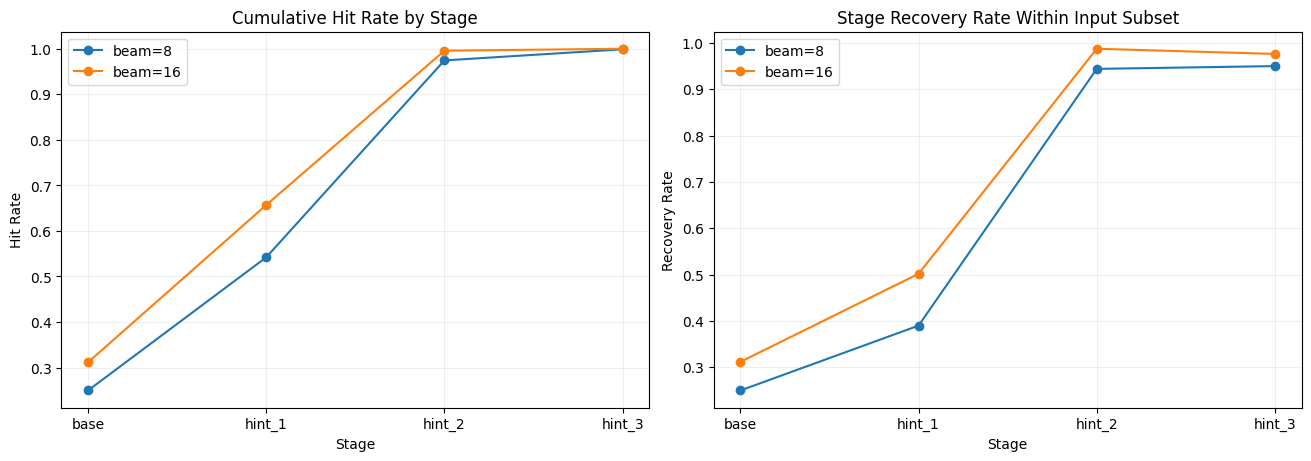

In [4]:
def extract_sid_tokens(text: str) -> list[str]:
    return SID_TOKEN_PATTERN.findall(text or '')


def stage_sort_key(stage_name: str) -> tuple[int, int]:
    if stage_name == 'base':
        return (0, 0)
    return (1, int(stage_name.split('_')[-1]))


def format_percent_columns(frame: pd.DataFrame, columns: list[str]) -> pd.DataFrame:
    out = frame.copy()
    for column in columns:
        if column in out.columns:
            out[column] = out[column].map(lambda value: f'{value:.2%}' if pd.notna(value) else '')
    return out


def build_stage_frame(summary_dict: dict) -> pd.DataFrame:
    rows = []
    for beam_size, beam_payload in sorted(((int(k), v) for k, v in summary_dict['results'].items()), key=lambda x: x[0]):
        for stage_name, stage_payload in sorted(beam_payload['stages'].items(), key=lambda item: stage_sort_key(item[0])):
            rows.append(
                {
                    'beam_size': beam_size,
                    'stage_name': stage_name,
                    'hint_depth': int(stage_payload['hint_depth']),
                    'input_subset_size': int(stage_payload['input_subset_size']),
                    'evaluated_subset_size': int(stage_payload['evaluated_subset_size']),
                    'stage_rule_hit_sample_count': int(stage_payload['stage_rule_hit_sample_count']),
                    'stage_rule_hit_sample_rate_within_input': float(stage_payload['stage_rule_hit_sample_rate_within_input']),
                    'cumulative_rule_hit_sample_rate': float(stage_payload['cumulative_rule_hit_sample_rate']),
                    'remaining_subset_size': int(stage_payload['remaining_subset_size']),
                }
            )
    frame = pd.DataFrame(rows)
    frame['stage_order'] = frame['stage_name'].map(stage_sort_key)
    return frame.sort_values(['beam_size', 'stage_order']).reset_index(drop=True)


stage_df = build_stage_frame(summary)
stage_table = stage_df.rename(
    columns={
        'beam_size': 'beam',
        'stage_name': 'stage',
        'input_subset_size': 'input_size',
        'stage_rule_hit_sample_count': 'stage_hit_count',
        'stage_rule_hit_sample_rate_within_input': 'stage_hit_rate',
        'cumulative_rule_hit_sample_rate': 'cumulative_hit_rate',
        'remaining_subset_size': 'remaining_size',
    }
)
display(format_percent_columns(stage_table, ['stage_hit_rate', 'cumulative_hit_rate']))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), constrained_layout=True)
for beam_size in beam_sizes:
    beam_frame = stage_df[stage_df['beam_size'] == beam_size]
    axes[0].plot(beam_frame['stage_name'], beam_frame['cumulative_rule_hit_sample_rate'], marker='o', label=f'beam={beam_size}')
    axes[1].plot(beam_frame['stage_name'], beam_frame['stage_rule_hit_sample_rate_within_input'], marker='o', label=f'beam={beam_size}')

axes[0].set_title('Cumulative Hit Rate by Stage')
axes[0].set_xlabel('Stage')
axes[0].set_ylabel('Hit Rate')
axes[0].grid(alpha=0.2)
axes[1].set_title('Stage Recovery Rate Within Input Subset')
axes[1].set_xlabel('Stage')
axes[1].set_ylabel('Recovery Rate')
axes[1].grid(alpha=0.2)
for axis in axes:
    axis.legend()
plt.show()

## Sample Difficulty Table

把多阶段结果压缩成样本级 difficulty label，后面所有 task / tree / sequence 分析都在这张表上展开。

In [5]:
focus_stages = details['results'][str(FOCUS_BEAM_SIZE)]['stages']


def build_sample_frame(samples: list[dict], stages_payload: dict[str, dict], max_hint_depth: int) -> pd.DataFrame:
    rows = {}
    final_stage_name = sorted(stages_payload, key=stage_sort_key)[-1]

    for sample_id, sample in enumerate(samples):
        extra_info = sample.get('extra_info', {})
        sid_tokens = extract_sid_tokens(sample['reward_model']['ground_truth'])
        rows[sample_id] = {
            'sample_id': sample_id,
            'source_index': extra_info.get('index'),
            'task': extra_info.get('task', 'unknown'),
            'task_label': TASK_LABELS.get(extra_info.get('task', 'unknown'), extra_info.get('task', 'unknown')),
            'ground_truth': sample['reward_model']['ground_truth'],
            'sid_tokens': sid_tokens,
            'sid_length': len(sid_tokens),
            'base_hit': False,
            'first_hit_depth': None,
            'first_hit_stage': None,
            'final_unsolved': False,
        }

    for stage_name in sorted(stages_payload, key=stage_sort_key):
        hint_depth = 0 if stage_name == 'base' else int(stage_name.split('_')[-1])
        for row in stages_payload[stage_name]['rows']:
            sample_row = rows[row['sample_id']]
            rule_hit_any = bool(row['group']['rule_hit_any'])
            if stage_name == 'base':
                sample_row['base_hit'] = rule_hit_any
            if rule_hit_any and sample_row['first_hit_depth'] is None:
                sample_row['first_hit_depth'] = hint_depth
                sample_row['first_hit_stage'] = stage_name
            if stage_name == final_stage_name:
                sample_row['final_unsolved'] = not rule_hit_any

    frame = pd.DataFrame(rows.values())
    frame['effective_hint_depth'] = frame['first_hit_depth'].fillna(max_hint_depth + 1).astype(int)
    frame['needs_hint'] = ~frame['base_hit']

    bucket_order = ['base'] + [f'hint_{depth}' for depth in range(1, max_hint_depth + 1)] + [f'unsolved_after_hint_{max_hint_depth}']
    frame['hint_bucket'] = pd.Categorical(
        frame['effective_hint_depth'].map(lambda depth: 'base' if depth == 0 else (f'hint_{depth}' if depth <= max_hint_depth else f'unsolved_after_hint_{max_hint_depth}')),
        categories=bucket_order,
        ordered=True,
    )
    return frame.sort_values(['task', 'sample_id']).reset_index(drop=True)


sample_df = build_sample_frame(train_samples, focus_stages, MAX_HINT_DEPTH)
sample_overview = (
    sample_df.groupby('task_label', observed=False)
    .agg(
        sample_count=('sample_id', 'size'),
        base_hit_rate=('base_hit', 'mean'),
        need_hint_rate=('needs_hint', 'mean'),
        hint_ge_2_rate=('effective_hint_depth', lambda s: (s >= 2).mean()),
        final_unsolved_rate=('final_unsolved', 'mean'),
        mean_effective_hint_depth=('effective_hint_depth', 'mean'),
    )
    .reset_index()
)
display(format_percent_columns(sample_overview, ['base_hit_rate', 'need_hint_rate', 'hint_ge_2_rate', 'final_unsolved_rate']))
display(sample_df[['sample_id', 'task_label', 'source_index', 'ground_truth', 'sid_tokens', 'hint_bucket']].head(12))

,task_label,sample_count,base_hit_rate,need_hint_rate,hint_ge_2_rate,final_unsolved_rate,mean_effective_hint_depth
0,hisTitle2sid,10000,8.69%,91.31%,61.24%,0.01%,1.533400
1,sid,84890,28.25%,71.75%,32.70%,0.01%,1.048062
2,title_desc2sid,11551,71.81%,28.19%,22.95%,0.03%,0.519522


,sample_id,task_label,source_index,ground_truth,sid_tokens,hint_bucket
0,0,sid,79786,<a_194><b_18><c_196><d_16>,"[<a_194>, <b_18>, <c_196>, <d_16>]",base
1,1,sid,53391,<a_125><b_122><c_78><d_50>,"[<a_125>, <b_122>, <c_78>, <d_50>]",hint_2
2,2,sid,68707,<a_194><b_134><c_104><d_0>,"[<a_194>, <b_134>, <c_104>, <d_0>]",hint_2
3,4,sid,44182,<a_77><b_171><c_238><d_92>,"[<a_77>, <b_171>, <c_238>, <d_92>]",hint_1
4,5,sid,80894,<a_199><b_156><c_53><d_207>,"[<a_199>, <b_156>, <c_53>, <d_207>]",hint_1
5,6,sid,31936,<a_19><b_157><c_212><d_87>,"[<a_19>, <b_157>, <c_212>, <d_87>]",hint_2
6,7,sid,45411,<a_150><b_68><c_242><d_104>,"[<a_150>, <b_68>, <c_242>, <d_104>]",hint_1
7,8,sid,5700,<a_125><b_156><c_88><d_97>,"[<a_125>, <b_156>, <c_88>, <d_97>]",hint_2
8,9,sid,46733,<a_234><b_63><c_195><d_144>,"[<a_234>, <b_63>, <c_195>, <d_144>]",hint_1
9,10,sid,5084,<a_59><b_94><c_178><d_215>,"[<a_59>, <b_94>, <c_178>, <d_215>]",hint_2


## Task Difficulty Comparison

先只看 task-level 现象，不解释原因：哪个 task 更依赖 hint，哪个 task 更常掉进 `hint_2+`。

hint_bucket,task,base,hint_1,hint_2,hint_3,unsolved_after_hint_3
0,sid,28.25%,39.04%,32.36%,0.34%,0.01%
1,hisTitle2sid,8.69%,30.07%,60.46%,0.77%,0.01%
2,title_desc2sid,71.81%,5.24%,22.17%,0.74%,0.03%


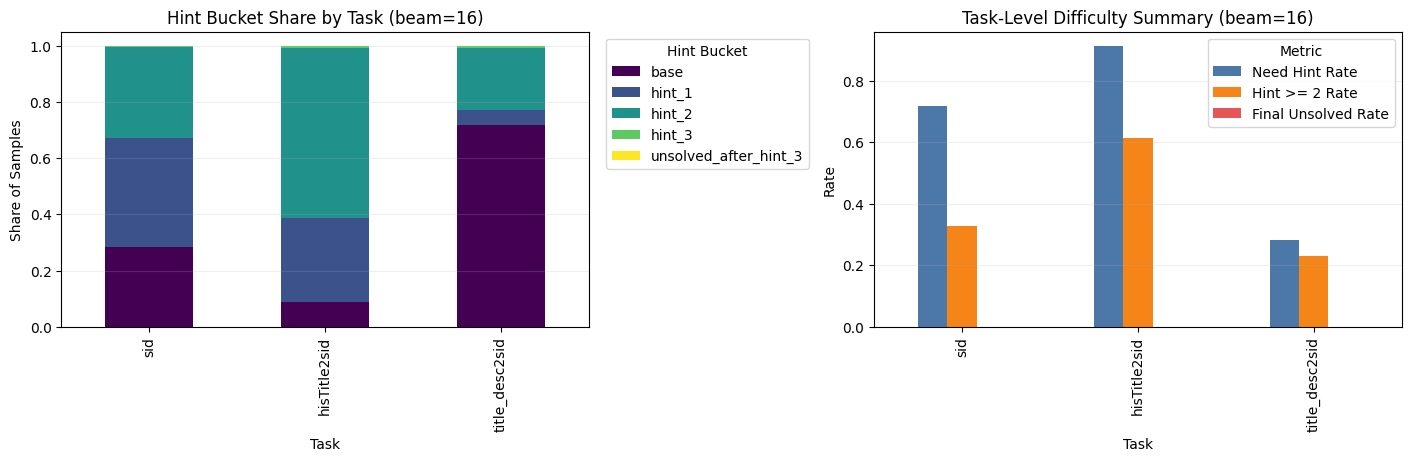

In [6]:
task_bucket_counts = (
    sample_df.groupby(['task_label', 'hint_bucket'], observed=False).size().rename('count').reset_index()
)
task_bucket_counts['share'] = task_bucket_counts.groupby('task_label')['count'].transform(lambda s: s / s.sum())

bucket_pivot = (
    task_bucket_counts.pivot(index='task_label', columns='hint_bucket', values='share')
    .reindex(TASK_ORDER)
    .fillna(0.0)
)
display(format_percent_columns(bucket_pivot.reset_index().rename(columns={'task_label': 'task'}), list(bucket_pivot.columns)))

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), constrained_layout=True)

bucket_pivot.plot(kind='bar', stacked=True, ax=axes[0], colormap='viridis')
axes[0].set_title(f'Hint Bucket Share by Task (beam={FOCUS_BEAM_SIZE})')
axes[0].set_xlabel('Task')
axes[0].set_ylabel('Share of Samples')
axes[0].legend(title='Hint Bucket', bbox_to_anchor=(1.02, 1), loc='upper left')
axes[0].grid(alpha=0.2, axis='y')

task_plot_df = sample_overview.set_index('task_label').reindex(TASK_ORDER)
task_plot_df = task_plot_df.rename(
    columns={
        'need_hint_rate': 'Need Hint Rate',
        'hint_ge_2_rate': 'Hint >= 2 Rate',
        'final_unsolved_rate': 'Final Unsolved Rate',
    }
)
task_plot_df[['Need Hint Rate', 'Hint >= 2 Rate', 'Final Unsolved Rate']].plot(
    kind='bar', ax=axes[1], color=['#4C78A8', '#F58518', '#E45756']
)
axes[1].set_title(f'Task-Level Difficulty Summary (beam={FOCUS_BEAM_SIZE})')
axes[1].set_xlabel('Task')
axes[1].set_ylabel('Rate')
axes[1].legend(title='Metric')
axes[1].grid(alpha=0.2, axis='y')
plt.show()

## Tree / Token Feature Build

下面把每个样本映射到两类结构量：

- token frequency：这个 SID token 在整个训练集、当前 task、当前 parent prefix 下有多常见。
- subtree statistics：当前 parent 下有多少孩子，这个 child 对应子树有多大，父节点分布有多不平衡。

为了避免单个 cell 太重，这部分拆成多个小 cell。

In [7]:
def normalize_sid_tokens(raw_tokens) -> list[str]:
    if isinstance(raw_tokens, list):
        return [str(token).strip() for token in raw_tokens if str(token).strip()]
    if isinstance(raw_tokens, str):
        token = raw_tokens.strip()
        return [token] if token else []
    return []


def sid_join(tokens: list[str]) -> str:
    return ''.join(tokens)


def prefix_key(tokens: list[str]) -> str:
    return sid_join(tokens) if tokens else 'ROOT'


def normalized_entropy(shares: list[float]) -> float:
    shares = [share for share in shares if share > 0]
    if len(shares) <= 1:
        return 0.0
    entropy = -sum(share * math.log(share) for share in shares)
    return entropy / math.log(len(shares))

In [8]:
def build_tree_edge_frame(index_data: dict[str, list[str] | str]) -> pd.DataFrame:
    child_counts_by_parent: dict[tuple[int, tuple[str, ...]], Counter[str]] = defaultdict(Counter)

    for raw_tokens in index_data.values():
        tokens = normalize_sid_tokens(raw_tokens)
        for depth, token in enumerate(tokens, start=1):
            parent = tuple(tokens[: depth - 1])
            child_counts_by_parent[(depth, parent)][token] += 1

    rows = []
    for (depth, parent), child_counter in child_counts_by_parent.items():
        ordered_children = sorted(child_counter.items(), key=lambda item: (-item[1], item[0]))
        parent_subtree_size = sum(child_counter.values())
        shares = [count / parent_subtree_size for _, count in ordered_children]
        parent_entropy = normalized_entropy(shares)
        parent_gini = 1.0 - sum(share * share for share in shares)
        parent_max_child_share = max(shares) if shares else 0.0
        sibling_count = len(ordered_children)
        parent_prefix = prefix_key(list(parent))

        for rank, (token, subtree_size) in enumerate(ordered_children, start=1):
            rows.append(
                {
                    'depth': depth,
                    'parent_prefix': parent_prefix,
                    'chosen_token': token,
                    'tree_subtree_size': subtree_size,
                    'tree_parent_subtree_size': parent_subtree_size,
                    'tree_child_share': subtree_size / parent_subtree_size,
                    'tree_child_rank': rank,
                    'tree_sibling_count': sibling_count,
                    'tree_parent_entropy': parent_entropy,
                    'tree_parent_gini': parent_gini,
                    'tree_parent_max_child_share': parent_max_child_share,
                }
            )

    return pd.DataFrame(rows)


tree_edge_df = build_tree_edge_frame(index_payload)
display(tree_edge_df.head(12))

,depth,parent_prefix,chosen_token,tree_subtree_size,tree_parent_subtree_size,tree_child_share,tree_child_rank,tree_sibling_count,tree_parent_entropy,tree_parent_gini,tree_parent_max_child_share
0,1,ROOT,<a_253>,385,6250,0.06160,1,41,0.931237,0.965282,0.0616
1,1,ROOT,<a_194>,327,6250,0.05232,2,41,0.931237,0.965282,0.0616
2,1,ROOT,<a_157>,322,6250,0.05152,3,41,0.931237,0.965282,0.0616
3,1,ROOT,<a_145>,302,6250,0.04832,4,41,0.931237,0.965282,0.0616
4,1,ROOT,<a_65>,274,6250,0.04384,5,41,0.931237,0.965282,0.0616
5,1,ROOT,<a_19>,244,6250,0.03904,6,41,0.931237,0.965282,0.0616
6,1,ROOT,<a_217>,242,6250,0.03872,7,41,0.931237,0.965282,0.0616
7,1,ROOT,<a_241>,237,6250,0.03792,8,41,0.931237,0.965282,0.0616
8,1,ROOT,<a_231>,233,6250,0.03728,9,41,0.931237,0.965282,0.0616
9,1,ROOT,<a_59>,229,6250,0.03664,10,41,0.931237,0.965282,0.0616


In [9]:
def build_training_frequency_frames(samples: list[dict]) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    global_token_counts: Counter[tuple[int, str]] = Counter()
    task_token_counts: Counter[tuple[str, int, str]] = Counter()
    task_parent_child_counts: Counter[tuple[str, int, str, str]] = Counter()
    depth_totals: Counter[int] = Counter()
    task_depth_totals: Counter[tuple[str, int]] = Counter()
    task_parent_totals: Counter[tuple[str, int, str]] = Counter()

    for sample in samples:
        task = sample.get('extra_info', {}).get('task', 'unknown')
        tokens = extract_sid_tokens(sample['reward_model']['ground_truth'])
        for depth, token in enumerate(tokens, start=1):
            parent_prefix = prefix_key(tokens[: depth - 1])
            global_token_counts[(depth, token)] += 1
            task_token_counts[(task, depth, token)] += 1
            task_parent_child_counts[(task, depth, parent_prefix, token)] += 1
            depth_totals[depth] += 1
            task_depth_totals[(task, depth)] += 1
            task_parent_totals[(task, depth, parent_prefix)] += 1

    global_rows = []
    for depth in sorted(depth_totals):
        depth_items = sorted(
            [(token, count) for (item_depth, token), count in global_token_counts.items() if item_depth == depth],
            key=lambda item: (-item[1], item[0]),
        )
        for rank, (token, count) in enumerate(depth_items, start=1):
            global_rows.append(
                {
                    'depth': depth,
                    'token': token,
                    'train_token_count': count,
                    'train_token_share': count / depth_totals[depth],
                    'train_token_rank': rank,
                }
            )

    task_rows = []
    for task, depth in sorted(task_depth_totals):
        depth_items = sorted(
            [
                (token, count)
                for (row_task, row_depth, token), count in task_token_counts.items()
                if row_task == task and row_depth == depth
            ],
            key=lambda item: (-item[1], item[0]),
        )
        for rank, (token, count) in enumerate(depth_items, start=1):
            task_rows.append(
                {
                    'task': task,
                    'depth': depth,
                    'token': token,
                    'task_token_count': count,
                    'task_token_share': count / task_depth_totals[(task, depth)],
                    'task_token_rank': rank,
                }
            )

    task_parent_rows = []
    for task, depth, parent_prefix in sorted(task_parent_totals):
        child_items = sorted(
            [
                (token, count)
                for (row_task, row_depth, row_parent_prefix, token), count in task_parent_child_counts.items()
                if row_task == task and row_depth == depth and row_parent_prefix == parent_prefix
            ],
            key=lambda item: (-item[1], item[0]),
        )
        total = task_parent_totals[(task, depth, parent_prefix)]
        for rank, (token, count) in enumerate(child_items, start=1):
            task_parent_rows.append(
                {
                    'task': task,
                    'depth': depth,
                    'parent_prefix': parent_prefix,
                    'token': token,
                    'task_parent_child_count': count,
                    'task_parent_child_share': count / total,
                    'task_parent_child_rank': rank,
                }
            )

    return pd.DataFrame(global_rows), pd.DataFrame(task_rows), pd.DataFrame(task_parent_rows)


global_token_df, task_token_df, task_parent_df = build_training_frequency_frames(train_samples)
display(global_token_df.head(12))
display(task_token_df.head(12))
display(task_parent_df.head(12))

,depth,token,train_token_count,train_token_share,train_token_rank
0,1,<a_241>,12117,0.113838,1
1,1,<a_194>,6920,0.065013,2
2,1,<a_125>,6469,0.060775,3
3,1,<a_65>,5092,0.047839,4
4,1,<a_253>,4631,0.043508,5
5,1,<a_157>,4622,0.043423,6
6,1,<a_145>,4309,0.040483,7
7,1,<a_146>,3820,0.035888,8
8,1,<a_77>,3798,0.035682,9
9,1,<a_144>,3793,0.035635,10


,task,depth,token,task_token_count,task_token_share,task_token_rank
0,task1_sid_sft,1,<a_241>,10443,0.123018,1
1,task1_sid_sft,1,<a_194>,5713,0.067299,2
2,task1_sid_sft,1,<a_125>,5388,0.063470,3
3,task1_sid_sft,1,<a_65>,4110,0.048416,4
4,task1_sid_sft,1,<a_157>,3583,0.042208,5
5,task1_sid_sft,1,<a_253>,3478,0.040971,6
6,task1_sid_sft,1,<a_145>,3298,0.038850,7
7,task1_sid_sft,1,<a_77>,3232,0.038073,8
8,task1_sid_sft,1,<a_146>,3134,0.036918,9
9,task1_sid_sft,1,<a_144>,3033,0.035729,10


,task,depth,parent_prefix,token,task_parent_child_count,task_parent_child_share,task_parent_child_rank
0,task1_sid_sft,1,ROOT,<a_241>,10443,0.123018,1
1,task1_sid_sft,1,ROOT,<a_194>,5713,0.067299,2
2,task1_sid_sft,1,ROOT,<a_125>,5388,0.063470,3
3,task1_sid_sft,1,ROOT,<a_65>,4110,0.048416,4
4,task1_sid_sft,1,ROOT,<a_157>,3583,0.042208,5
5,task1_sid_sft,1,ROOT,<a_253>,3478,0.040971,6
6,task1_sid_sft,1,ROOT,<a_145>,3298,0.038850,7
7,task1_sid_sft,1,ROOT,<a_77>,3232,0.038073,8
8,task1_sid_sft,1,ROOT,<a_146>,3134,0.036918,9
9,task1_sid_sft,1,ROOT,<a_144>,3033,0.035729,10


In [10]:
def build_lookup(frame: pd.DataFrame, key_columns: list[str], value_columns: list[str]) -> dict[tuple, dict]:
    lookup = {}
    for row in frame.to_dict('records'):
        lookup[tuple(row[column] for column in key_columns)] = {column: row[column] for column in value_columns}
    return lookup


def attach_depth_metrics(
    frame: pd.DataFrame,
    tree_lookup: dict[tuple, dict],
    global_token_lookup: dict[tuple, dict],
    task_token_lookup: dict[tuple, dict],
    task_parent_lookup: dict[tuple, dict],
) -> pd.DataFrame:
    out = frame.copy()
    max_depth = int(out['sid_length'].max())

    for depth in range(1, max_depth + 1):
        token_column = f'sid_token_{depth}'
        parent_column = f'sid_parent_prefix_{depth}'
        out[token_column] = out['sid_tokens'].map(lambda tokens: tokens[depth - 1] if len(tokens) >= depth else None)
        out[parent_column] = out['sid_tokens'].map(lambda tokens: prefix_key(tokens[: depth - 1]) if len(tokens) >= depth else None)

        train_token_count = []
        train_token_share = []
        train_token_rank = []
        task_token_count = []
        task_token_share = []
        task_token_rank = []
        task_parent_child_count = []
        task_parent_child_share = []
        task_parent_child_rank = []
        tree_subtree_size = []
        tree_parent_subtree_size = []
        tree_child_share = []
        tree_child_rank = []
        tree_sibling_count = []
        tree_parent_entropy = []
        tree_parent_gini = []
        tree_parent_max_child_share = []

        for task, parent_prefix, token in out[['task', parent_column, token_column]].itertuples(index=False, name=None):
            if token is None:
                train_token_count.append(None)
                train_token_share.append(None)
                train_token_rank.append(None)
                task_token_count.append(None)
                task_token_share.append(None)
                task_token_rank.append(None)
                task_parent_child_count.append(None)
                task_parent_child_share.append(None)
                task_parent_child_rank.append(None)
                tree_subtree_size.append(None)
                tree_parent_subtree_size.append(None)
                tree_child_share.append(None)
                tree_child_rank.append(None)
                tree_sibling_count.append(None)
                tree_parent_entropy.append(None)
                tree_parent_gini.append(None)
                tree_parent_max_child_share.append(None)
                continue

            global_metrics = global_token_lookup.get((depth, token), {})
            task_metrics = task_token_lookup.get((task, depth, token), {})
            task_parent_metrics = task_parent_lookup.get((task, depth, parent_prefix, token), {})
            tree_metrics = tree_lookup.get((depth, parent_prefix, token), {})

            train_token_count.append(global_metrics.get('train_token_count'))
            train_token_share.append(global_metrics.get('train_token_share'))
            train_token_rank.append(global_metrics.get('train_token_rank'))
            task_token_count.append(task_metrics.get('task_token_count'))
            task_token_share.append(task_metrics.get('task_token_share'))
            task_token_rank.append(task_metrics.get('task_token_rank'))
            task_parent_child_count.append(task_parent_metrics.get('task_parent_child_count'))
            task_parent_child_share.append(task_parent_metrics.get('task_parent_child_share'))
            task_parent_child_rank.append(task_parent_metrics.get('task_parent_child_rank'))
            tree_subtree_size.append(tree_metrics.get('tree_subtree_size'))
            tree_parent_subtree_size.append(tree_metrics.get('tree_parent_subtree_size'))
            tree_child_share.append(tree_metrics.get('tree_child_share'))
            tree_child_rank.append(tree_metrics.get('tree_child_rank'))
            tree_sibling_count.append(tree_metrics.get('tree_sibling_count'))
            tree_parent_entropy.append(tree_metrics.get('tree_parent_entropy'))
            tree_parent_gini.append(tree_metrics.get('tree_parent_gini'))
            tree_parent_max_child_share.append(tree_metrics.get('tree_parent_max_child_share'))

        out[f'train_token_count_d{depth}'] = train_token_count
        out[f'train_token_share_d{depth}'] = train_token_share
        out[f'train_token_rank_d{depth}'] = train_token_rank
        out[f'task_token_count_d{depth}'] = task_token_count
        out[f'task_token_share_d{depth}'] = task_token_share
        out[f'task_token_rank_d{depth}'] = task_token_rank
        out[f'task_parent_child_count_d{depth}'] = task_parent_child_count
        out[f'task_parent_child_share_d{depth}'] = task_parent_child_share
        out[f'task_parent_child_rank_d{depth}'] = task_parent_child_rank
        out[f'tree_subtree_size_d{depth}'] = tree_subtree_size
        out[f'tree_parent_subtree_size_d{depth}'] = tree_parent_subtree_size
        out[f'tree_child_share_d{depth}'] = tree_child_share
        out[f'tree_child_rank_d{depth}'] = tree_child_rank
        out[f'tree_sibling_count_d{depth}'] = tree_sibling_count
        out[f'tree_parent_entropy_d{depth}'] = tree_parent_entropy
        out[f'tree_parent_gini_d{depth}'] = tree_parent_gini
        out[f'tree_parent_max_child_share_d{depth}'] = tree_parent_max_child_share

    return out

In [11]:
def add_required_hint_metrics(frame: pd.DataFrame, max_hint_depth: int) -> pd.DataFrame:
    out = frame.copy()
    metric_prefixes = [
        'sid_token',
        'sid_parent_prefix',
        'train_token_count',
        'train_token_share',
        'train_token_rank',
        'task_token_count',
        'task_token_share',
        'task_token_rank',
        'task_parent_child_count',
        'task_parent_child_share',
        'task_parent_child_rank',
        'tree_subtree_size',
        'tree_parent_subtree_size',
        'tree_child_share',
        'tree_child_rank',
        'tree_sibling_count',
        'tree_parent_entropy',
        'tree_parent_gini',
        'tree_parent_max_child_share',
    ]

    for metric_prefix in metric_prefixes:
        values = []
        for depth, row in zip(out['effective_hint_depth'], out.to_dict('records')):
            if depth <= 0 or depth > max_hint_depth:
                values.append(None)
                continue
            values.append(row.get(f'{metric_prefix}_d{depth}'))
        out[f'required_{metric_prefix}'] = values

    return out


def lookup_required_value(row: pd.Series, prefix: str, depth: int):
    if depth <= 0 or depth > MAX_HINT_DEPTH:
        return None
    candidates = [f'{prefix}_{depth}', f'{prefix}_d{depth}']
    for candidate in candidates:
        if candidate in row.index:
            return row[candidate]
    return None

In [12]:
tree_lookup = build_lookup(
    tree_edge_df,
    ['depth', 'parent_prefix', 'chosen_token'],
    [
        'tree_subtree_size',
        'tree_parent_subtree_size',
        'tree_child_share',
        'tree_child_rank',
        'tree_sibling_count',
        'tree_parent_entropy',
        'tree_parent_gini',
        'tree_parent_max_child_share',
    ],
)
global_token_lookup = build_lookup(global_token_df, ['depth', 'token'], ['train_token_count', 'train_token_share', 'train_token_rank'])
task_token_lookup = build_lookup(task_token_df, ['task', 'depth', 'token'], ['task_token_count', 'task_token_share', 'task_token_rank'])
task_parent_lookup = build_lookup(
    task_parent_df,
    ['task', 'depth', 'parent_prefix', 'token'],
    ['task_parent_child_count', 'task_parent_child_share', 'task_parent_child_rank'],
)

sample_df = attach_depth_metrics(sample_df, tree_lookup, global_token_lookup, task_token_lookup, task_parent_lookup)
sample_df = add_required_hint_metrics(sample_df, MAX_HINT_DEPTH)

sample_df['required_sid_token'] = sample_df.apply(
    lambda row: lookup_required_value(row, 'sid_token', int(row['effective_hint_depth'])),
    axis=1,
)
sample_df['required_sid_parent_prefix'] = sample_df.apply(
    lambda row: lookup_required_value(row, 'sid_parent_prefix', int(row['effective_hint_depth'])),
    axis=1,
)
sample_df['required_tree_child_rank'] = sample_df.apply(
    lambda row: lookup_required_value(row, 'tree_child_rank', int(row['effective_hint_depth'])),
    axis=1,
)

validation_frame = sample_df[
    [
        'task_label',
        'ground_truth',
        'hint_bucket',
        'effective_hint_depth',
        'required_sid_token',
        'required_sid_parent_prefix',
        'required_train_token_count',
        'required_task_parent_child_share',
        'required_tree_subtree_size',
        'required_tree_parent_max_child_share',
        'required_tree_child_rank',
    ]
].head(15)

display(validation_frame)
print('required_sid_token null rate among hinted samples =', sample_df[sample_df['effective_hint_depth'].between(1, MAX_HINT_DEPTH)]['required_sid_token'].isna().mean())

,task_label,ground_truth,hint_bucket,effective_hint_depth,required_sid_token,required_sid_parent_prefix,required_train_token_count,required_task_parent_child_share,required_tree_subtree_size,required_tree_parent_max_child_share,required_tree_child_rank
0,sid,<a_194><b_18><c_196><d_16>,base,0,None,None,NaN,NaN,NaN,NaN,NaN
1,sid,<a_125><b_122><c_78><d_50>,hint_2,2,<b_122>,<a_125>,567.0,0.022829,4.0,0.113636,19.0
2,sid,<a_194><b_134><c_104><d_0>,hint_2,2,<b_134>,<a_194>,767.0,0.003676,4.0,0.070336,25.0
3,sid,<a_77><b_171><c_238><d_92>,hint_1,1,<a_77>,ROOT,3798.0,0.038073,107.0,0.061600,25.0
4,sid,<a_199><b_156><c_53><d_207>,hint_1,1,<a_199>,ROOT,2547.0,0.023960,129.0,0.061600,23.0
5,sid,<a_19><b_157><c_212><d_87>,hint_2,2,<b_157>,<a_19>,444.0,0.030806,10.0,0.073770,4.0
6,sid,<a_150><b_68><c_242><d_104>,hint_1,1,<a_150>,ROOT,2618.0,0.023937,187.0,0.061600,17.0
7,sid,<a_125><b_156><c_88><d_97>,hint_2,2,<b_156>,<a_125>,2734.0,0.013363,8.0,0.113636,6.0
8,sid,<a_234><b_63><c_195><d_144>,hint_1,1,<a_234>,ROOT,2301.0,0.021687,161.0,0.061600,22.0
9,sid,<a_59><b_94><c_178><d_215>,hint_2,2,<b_94>,<a_59>,439.0,0.014263,6.0,0.052402,11.0


required_sid_token null rate among hinted samples = 0.0


## Branch Concentration

这里不再只看均值，而是直接找 deep-hint / final-unsolved 样本集中在哪些 token 和 parent prefix 上。`share_lift > 1` 表示某个 group 在困难子集里相对过密。

In [13]:
def build_lift_table(frame: pd.DataFrame, group_column: str, focus_mask: pd.Series, baseline_mask: pd.Series, min_focus_count: int = 5) -> pd.DataFrame:
    focus_counts = frame.loc[focus_mask & frame[group_column].notna(), group_column].value_counts().rename('focus_count')
    baseline_counts = frame.loc[baseline_mask & frame[group_column].notna(), group_column].value_counts().rename('baseline_count')
    merged = pd.concat([focus_counts, baseline_counts], axis=1).fillna(0.0)
    if merged.empty:
        return pd.DataFrame(columns=[group_column, 'focus_count', 'baseline_count', 'focus_share', 'baseline_share', 'share_lift'])
    merged = merged[merged['focus_count'] >= min_focus_count].copy()
    if merged.empty:
        return pd.DataFrame(columns=[group_column, 'focus_count', 'baseline_count', 'focus_share', 'baseline_share', 'share_lift'])
    merged['focus_share'] = merged['focus_count'] / merged['focus_count'].sum()
    merged['baseline_share'] = merged['baseline_count'] / merged['baseline_count'].sum()
    merged['share_lift'] = merged['focus_share'] / merged['baseline_share'].replace(0, pd.NA)
    return merged.sort_values(['share_lift', 'focus_count'], ascending=[False, False]).reset_index(names=group_column)


for task_label in ['sid', 'hisTitle2sid']:
    task_frame = sample_df[sample_df['task_label'] == task_label].copy()
    need_hint_mask = task_frame['effective_hint_depth'] >= 1
    deep_hint_mask = task_frame['effective_hint_depth'] >= 2
    unsolved_mask = task_frame['final_unsolved']

    display(Markdown(f'### `{task_label}`: deep-hint token lift'))
    display(build_lift_table(task_frame, 'required_sid_token', deep_hint_mask, need_hint_mask, min_focus_count=10).head(12))

    display(Markdown(f'### `{task_label}`: deep-hint parent-prefix lift'))
    display(build_lift_table(task_frame, 'required_sid_parent_prefix', deep_hint_mask, need_hint_mask, min_focus_count=10).head(12))

    if unsolved_mask.any():
        display(Markdown(f'### `{task_label}`: final-unsolved parent-prefix lift'))
        display(build_lift_table(task_frame, 'required_sid_parent_prefix', unsolved_mask, need_hint_mask, min_focus_count=1).head(12))

### `sid`: deep-hint token lift

,required_sid_token,focus_count,baseline_count,focus_share,baseline_share,share_lift
0,<b_153>,409.0,409,0.014849,0.014849,1.0
1,<b_205>,366.0,366,0.013288,0.013288,1.0
2,<b_197>,323.0,323,0.011727,0.011727,1.0
3,<b_139>,316.0,316,0.011473,0.011473,1.0
4,<b_162>,273.0,273,0.009911,0.009911,1.0
5,<b_195>,261.0,261,0.009476,0.009476,1.0
6,<b_18>,259.0,259,0.009403,0.009403,1.0
7,<b_24>,257.0,257,0.009331,0.009331,1.0
8,<b_171>,246.0,246,0.008931,0.008931,1.0
9,<b_60>,244.0,244,0.008859,0.008859,1.0


### `sid`: deep-hint parent-prefix lift

,required_sid_parent_prefix,focus_count,baseline_count,focus_share,baseline_share,share_lift
0,<a_194>,2346.0,2346,0.084693,0.084693,1.0
1,<a_157>,2234.0,2234,0.080650,0.080650,1.0
2,<a_241>,1856.0,1856,0.067004,0.067004,1.0
3,<a_145>,1636.0,1636,0.059061,0.059061,1.0
4,<a_125>,1617.0,1617,0.058375,0.058375,1.0
5,<a_253>,1460.0,1460,0.052708,0.052708,1.0
6,<a_65>,1411.0,1411,0.050939,0.050939,1.0
7,<a_198>,1297.0,1297,0.046823,0.046823,1.0
8,<a_146>,1230.0,1230,0.044404,0.044404,1.0
9,<a_19>,1037.0,1037,0.037437,0.037437,1.0


### `sid`: final-unsolved parent-prefix lift

...

,required_sid_token,focus_count,baseline_count,focus_share,baseline_share,share_lift
0,<b_196>,130.0,130,0.021952,0.021952,1.0
1,<b_254>,98.0,98,0.016548,0.016548,1.0
2,<b_125>,82.0,82,0.013847,0.013847,1.0
3,<b_197>,76.0,76,0.012834,0.012834,1.0
4,<b_162>,70.0,70,0.011820,0.011820,1.0
5,<b_195>,68.0,68,0.011483,0.011483,1.0
6,<b_171>,68.0,68,0.011483,0.011483,1.0
7,<b_205>,65.0,65,0.010976,0.010976,1.0
8,<b_24>,65.0,65,0.010976,0.010976,1.0
9,<b_18>,65.0,65,0.010976,0.010976,1.0


### `hisTitle2sid`: deep-hint parent-prefix lift

,required_sid_parent_prefix,focus_count,baseline_count,focus_share,baseline_share,share_lift
0,<a_194>,474.0,474,0.078205,0.078205,1.0
1,<a_241>,449.0,449,0.074080,0.074080,1.0
2,<a_125>,367.0,367,0.060551,0.060551,1.0
3,<a_253>,348.0,348,0.057416,0.057416,1.0
4,<a_65>,314.0,314,0.051807,0.051807,1.0
5,<a_157>,309.0,309,0.050982,0.050982,1.0
6,<a_145>,306.0,306,0.050487,0.050487,1.0
7,<a_170>,234.0,234,0.038607,0.038607,1.0
8,<a_105>,223.0,223,0.036793,0.036793,1.0
9,<a_198>,219.0,219,0.036133,0.036133,1.0


### `hisTitle2sid`: final-unsolved parent-prefix lift

,required_sid_parent_prefix,focus_count,baseline_count,focus_share,baseline_share,share_lift


## Frequency vs Subtree Interaction

把需要 hint 的样本同时按 `required_train_token_count` 和 `required_tree_subtree_size` 分桶，看 deep-hint 是否集中在“低频 + 小子树”的联合区域。

,freq_bin,subtree_bin,sample_count,deep_hint_rate,mean_hint_depth,task_label
0,freq_Q1,subtree_Q1,8282,99.32%,2.007486,sid
1,freq_Q1,subtree_Q2,5757,96.61%,1.969081,sid
2,freq_Q1,subtree_Q3,80,100.00%,2.000000,sid
3,freq_Q1,subtree_Q4,0,,NaN,sid
4,freq_Q2,subtree_Q1,5048,100.00%,2.019017,sid
5,freq_Q2,subtree_Q2,6707,100.00%,2.007902,sid
6,freq_Q2,subtree_Q3,2617,0.96%,1.009553,sid
7,freq_Q2,subtree_Q4,0,,NaN,sid
8,freq_Q3,subtree_Q1,723,100.00%,2.005533,sid
9,freq_Q3,subtree_Q2,1175,100.00%,2.000000,sid


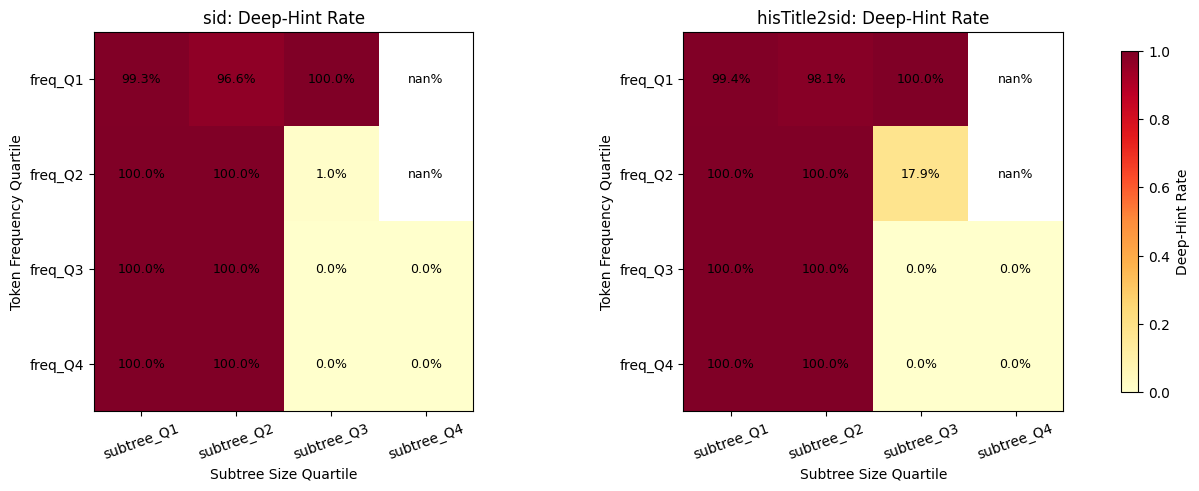

In [14]:
def add_quartile_bin(frame: pd.DataFrame, column: str, prefix: str) -> pd.Series:
    valid = frame[column].dropna()
    if valid.nunique() < 4:
        return pd.Series(['all'] * len(frame), index=frame.index)
    ranked = frame[column].rank(method='first')
    return pd.qcut(ranked, 4, labels=[f'{prefix}_Q1', f'{prefix}_Q2', f'{prefix}_Q3', f'{prefix}_Q4'])


need_hint_only = sample_df[sample_df['effective_hint_depth'].between(1, MAX_HINT_DEPTH)].copy()
need_hint_only['is_deep_hint'] = need_hint_only['effective_hint_depth'] >= 2
need_hint_only['freq_bin'] = add_quartile_bin(need_hint_only, 'required_train_token_count', 'freq')
need_hint_only['subtree_bin'] = add_quartile_bin(need_hint_only, 'required_tree_subtree_size', 'subtree')

heatmap_rows = []
for task_label in ['sid', 'hisTitle2sid']:
    task_frame = need_hint_only[need_hint_only['task_label'] == task_label].copy()
    grouped = (
        task_frame.groupby(['freq_bin', 'subtree_bin'], observed=False)
        .agg(
            sample_count=('sample_id', 'size'),
            deep_hint_rate=('is_deep_hint', 'mean'),
            mean_hint_depth=('effective_hint_depth', 'mean'),
        )
        .reset_index()
    )
    grouped['task_label'] = task_label
    heatmap_rows.append(grouped)

heatmap_df = pd.concat(heatmap_rows, ignore_index=True)
display(format_percent_columns(heatmap_df, ['deep_hint_rate']))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), constrained_layout=True)
for axis, task_label in zip(axes, ['sid', 'hisTitle2sid']):
    subset = heatmap_df[heatmap_df['task_label'] == task_label]
    pivot = subset.pivot(index='freq_bin', columns='subtree_bin', values='deep_hint_rate')
    im = axis.imshow(pivot.values, cmap='YlOrRd', vmin=0.0, vmax=1.0)
    axis.set_title(f'{task_label}: Deep-Hint Rate')
    axis.set_xticks(range(len(pivot.columns)))
    axis.set_xticklabels(list(pivot.columns), rotation=20)
    axis.set_yticks(range(len(pivot.index)))
    axis.set_yticklabels(list(pivot.index))
    axis.set_xlabel('Subtree Size Quartile')
    axis.set_ylabel('Token Frequency Quartile')
    for row_idx in range(len(pivot.index)):
        for col_idx in range(len(pivot.columns)):
            value = pivot.iloc[row_idx, col_idx]
            axis.text(col_idx, row_idx, f'{value:.1%}', ha='center', va='center', color='black', fontsize=9)

fig.colorbar(im, ax=axes, shrink=0.9, label='Deep-Hint Rate')
plt.show()

## Question 1: Are Required Hint Tokens Low Frequency?

这一步回到更直观的均值表：当样本需要 `hint_1 / hint_2 / hint_3` 时，对应 token 在全训练集、当前 task、当前 parent 下到底有多常见。

,task_label,hint_bucket,sample_count,mean_global_token_count,median_global_token_count,mean_global_token_share,mean_task_token_share,mean_parent_conditional_share
0,hisTitle2sid,base,0,NaN,NaN,,,
1,hisTitle2sid,hint_1,3007,4288.451945,3644.0,4.03%,4.16%,4.16%
2,hisTitle2sid,hint_2,6046,737.255045,558.0,0.69%,0.72%,4.61%
3,hisTitle2sid,hint_3,77,646.116883,549.0,0.61%,0.63%,15.80%
4,hisTitle2sid,unsolved_after_hint_3,0,NaN,NaN,,,
5,sid,base,0,NaN,NaN,,,
6,sid,hint_1,33144,3671.105781,3248.0,3.45%,3.50%,3.50%
7,sid,hint_2,27469,636.716335,516.0,0.60%,0.60%,3.09%
8,sid,hint_3,288,631.788194,549.0,0.59%,0.60%,13.13%
9,sid,unsolved_after_hint_3,0,NaN,NaN,,,


/mnt/dolphinfs/hdd_pool/docker/user/hadoop-hmart-poistar/fanghaotian/conda/envs/grec/lib/python3.10/site-packages/pandas/core/arrays/categorical.py:595: RuntimeWarning: invalid value encountered in cast
  np.array(self.categories._na_value).astype(dtype)
/mnt/dolphinfs/hdd_pool/docker/user/hadoop-hmart-poistar/fanghaotian/conda/envs/grec/lib/python3.10/site-packages/pandas/core/arrays/categorical.py:595: RuntimeWarning: invalid value encountered in cast
  np.array(self.categories._na_value).astype(dtype)
/mnt/dolphinfs/hdd_pool/docker/user/hadoop-hmart-poistar/fanghaotian/conda/envs/grec/lib/python3.10/site-packages/pandas/core/arrays/categorical.py:595: RuntimeWarning: invalid value encountered in cast
  np.array(self.categories._na_value).astype(dtype)
/mnt/dolphinfs/hdd_pool/docker/user/hadoop-hmart-poistar/fanghaotian/conda/envs/grec/lib/python3.10/site-packages/pandas/core/arrays/categorical.py:595: RuntimeWarning: invalid value encountered in cast
  np.array(self.categories._na_v

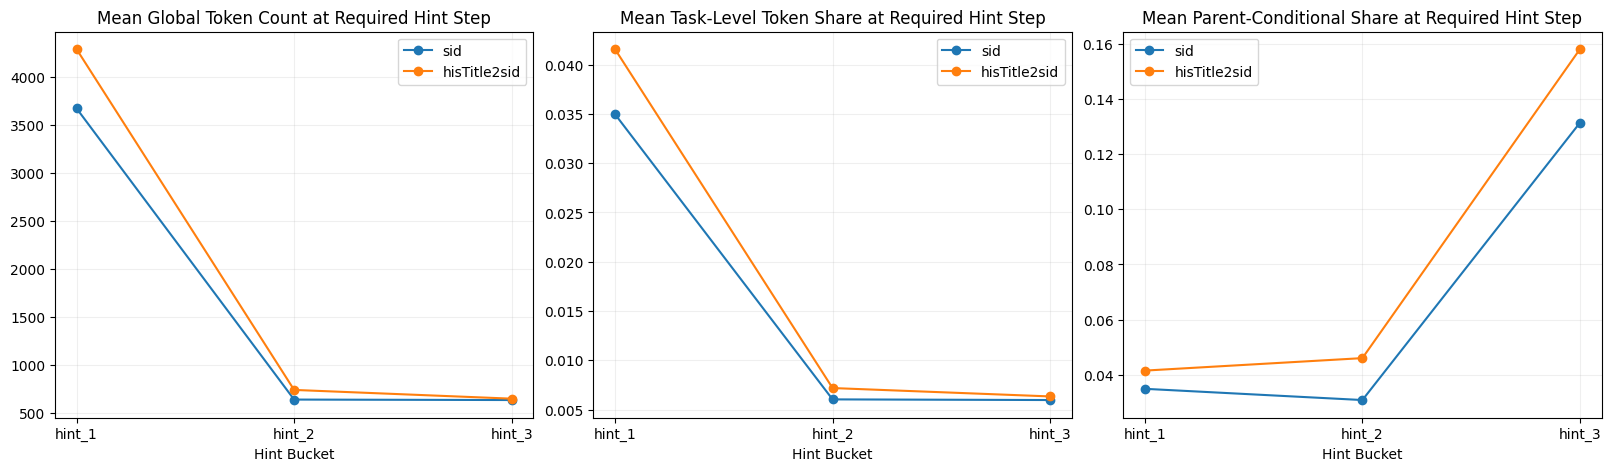

In [15]:
required_hint_summary = (
    sample_df[sample_df['effective_hint_depth'].between(1, MAX_HINT_DEPTH)]
    .groupby(['task_label', 'hint_bucket'], observed=False)
    .agg(
        sample_count=('sample_id', 'size'),
        mean_global_token_count=('required_train_token_count', 'mean'),
        median_global_token_count=('required_train_token_count', 'median'),
        mean_global_token_share=('required_train_token_share', 'mean'),
        mean_task_token_share=('required_task_token_share', 'mean'),
        mean_parent_conditional_share=('required_task_parent_child_share', 'mean'),
    )
    .reset_index()
)
display(format_percent_columns(required_hint_summary, ['mean_global_token_share', 'mean_task_token_share', 'mean_parent_conditional_share']))

fig, axes = plt.subplots(1, 3, figsize=(16, 4.6), constrained_layout=True)
plot_df = required_hint_summary[required_hint_summary['task_label'].isin(['sid', 'hisTitle2sid'])].copy()

for task_label in ['sid', 'hisTitle2sid']:
    task_frame = plot_df[plot_df['task_label'] == task_label]
    axes[0].plot(task_frame['hint_bucket'].astype(str), task_frame['mean_global_token_count'], marker='o', label=task_label)
    axes[1].plot(task_frame['hint_bucket'].astype(str), task_frame['mean_task_token_share'], marker='o', label=task_label)
    axes[2].plot(task_frame['hint_bucket'].astype(str), task_frame['mean_parent_conditional_share'], marker='o', label=task_label)

axes[0].set_title('Mean Global Token Count at Required Hint Step')
axes[1].set_title('Mean Task-Level Token Share at Required Hint Step')
axes[2].set_title('Mean Parent-Conditional Share at Required Hint Step')
for axis in axes:
    axis.set_xlabel('Hint Bucket')
    axis.grid(alpha=0.2)
    axis.legend()
plt.show()

## Question 2 / 3: Are Deep-Hint Samples Linked to Smaller or More Imbalanced Subtrees?

这里把 subtree size、sibling count、entropy、`max_child_share` 放回 hint depth 维度上，看难度和 tree 结构的关系。

,task_label,hint_bucket,sample_count,mean_subtree_size,mean_sibling_count,mean_parent_entropy,mean_parent_gini,mean_parent_max_child_share,mean_child_share
0,hisTitle2sid,base,0,NaN,NaN,NaN,NaN,,
1,hisTitle2sid,hint_1,3007,186.442634,41.000000,0.931237,0.965282,6.16%,2.98%
2,hisTitle2sid,hint_2,6046,6.284982,74.553920,0.910463,0.970520,8.14%,2.89%
3,hisTitle2sid,hint_3,77,3.129870,12.792208,0.878201,0.815785,29.05%,13.69%
4,hisTitle2sid,unsolved_after_hint_3,0,NaN,NaN,NaN,NaN,,
5,sid,base,0,NaN,NaN,NaN,NaN,,
6,sid,hint_1,33144,192.228910,41.000000,0.931237,0.965282,6.16%,3.08%
7,sid,hint_2,27469,6.534894,77.154247,0.908880,0.971193,8.05%,2.83%
8,sid,hint_3,288,3.458333,13.645833,0.894275,0.841812,26.13%,14.90%
9,sid,unsolved_after_hint_3,0,NaN,NaN,NaN,NaN,,


/mnt/dolphinfs/hdd_pool/docker/user/hadoop-hmart-poistar/fanghaotian/conda/envs/grec/lib/python3.10/site-packages/pandas/core/arrays/categorical.py:595: RuntimeWarning: invalid value encountered in cast
  np.array(self.categories._na_value).astype(dtype)
/mnt/dolphinfs/hdd_pool/docker/user/hadoop-hmart-poistar/fanghaotian/conda/envs/grec/lib/python3.10/site-packages/pandas/core/arrays/categorical.py:595: RuntimeWarning: invalid value encountered in cast
  np.array(self.categories._na_value).astype(dtype)
/mnt/dolphinfs/hdd_pool/docker/user/hadoop-hmart-poistar/fanghaotian/conda/envs/grec/lib/python3.10/site-packages/pandas/core/arrays/categorical.py:595: RuntimeWarning: invalid value encountered in cast
  np.array(self.categories._na_value).astype(dtype)
/mnt/dolphinfs/hdd_pool/docker/user/hadoop-hmart-poistar/fanghaotian/conda/envs/grec/lib/python3.10/site-packages/pandas/core/arrays/categorical.py:595: RuntimeWarning: invalid value encountered in cast
  np.array(self.categories._na_v

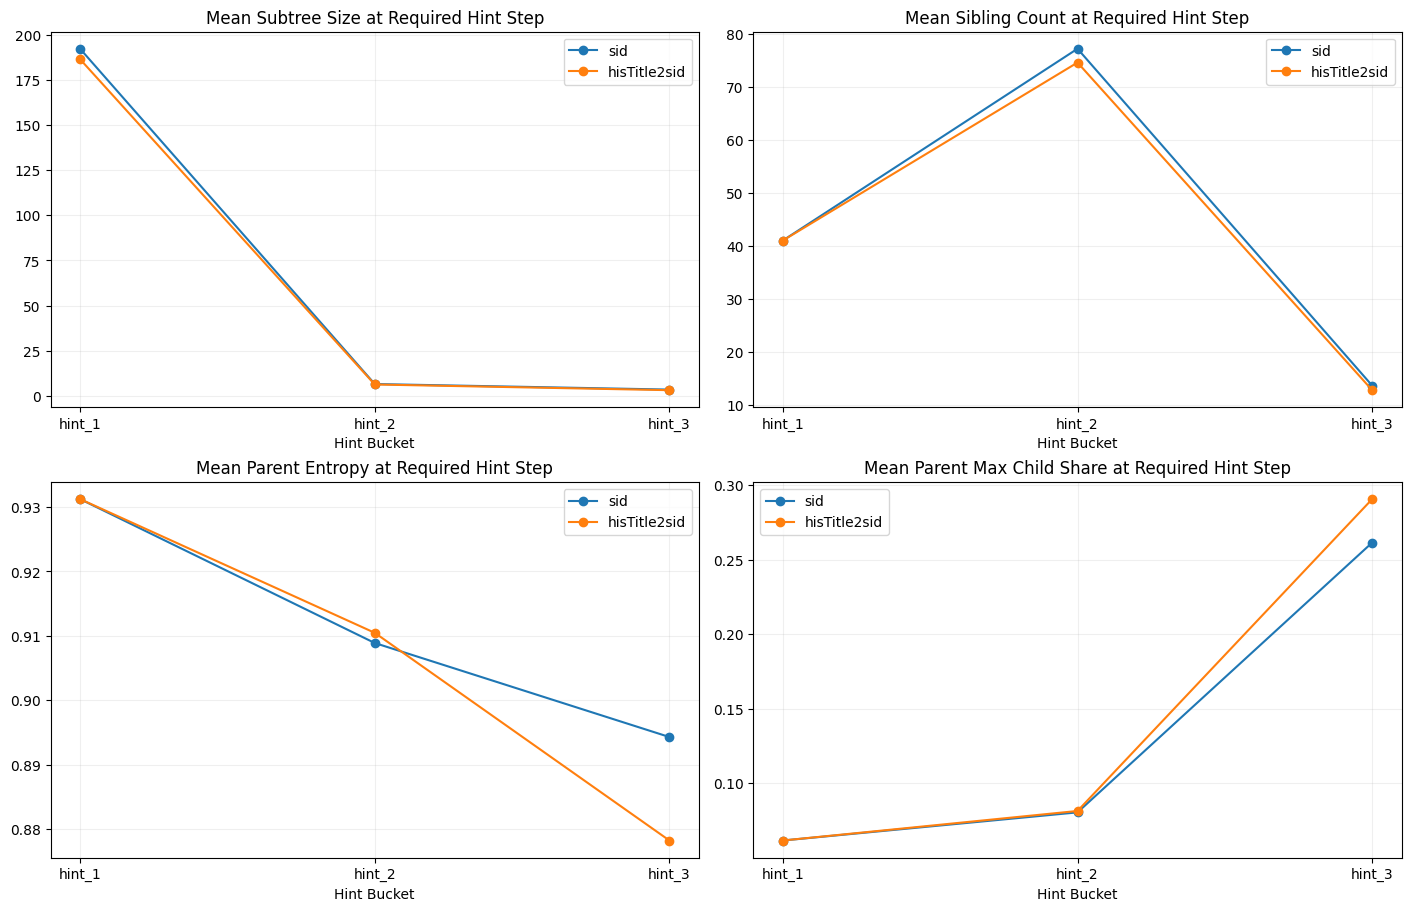

In [16]:
structure_summary = (
    sample_df[sample_df['effective_hint_depth'].between(1, MAX_HINT_DEPTH)]
    .groupby(['task_label', 'hint_bucket'], observed=False)
    .agg(
        sample_count=('sample_id', 'size'),
        mean_subtree_size=('required_tree_subtree_size', 'mean'),
        mean_sibling_count=('required_tree_sibling_count', 'mean'),
        mean_parent_entropy=('required_tree_parent_entropy', 'mean'),
        mean_parent_gini=('required_tree_parent_gini', 'mean'),
        mean_parent_max_child_share=('required_tree_parent_max_child_share', 'mean'),
        mean_child_share=('required_tree_child_share', 'mean'),
    )
    .reset_index()
)
display(format_percent_columns(structure_summary, ['mean_parent_max_child_share', 'mean_child_share']))

fig, axes = plt.subplots(2, 2, figsize=(14, 9), constrained_layout=True)
plot_df = structure_summary[structure_summary['task_label'].isin(['sid', 'hisTitle2sid'])].copy()

for task_label in ['sid', 'hisTitle2sid']:
    task_frame = plot_df[plot_df['task_label'] == task_label]
    axes[0, 0].plot(task_frame['hint_bucket'].astype(str), task_frame['mean_subtree_size'], marker='o', label=task_label)
    axes[0, 1].plot(task_frame['hint_bucket'].astype(str), task_frame['mean_sibling_count'], marker='o', label=task_label)
    axes[1, 0].plot(task_frame['hint_bucket'].astype(str), task_frame['mean_parent_entropy'], marker='o', label=task_label)
    axes[1, 1].plot(task_frame['hint_bucket'].astype(str), task_frame['mean_parent_max_child_share'], marker='o', label=task_label)

axes[0, 0].set_title('Mean Subtree Size at Required Hint Step')
axes[0, 1].set_title('Mean Sibling Count at Required Hint Step')
axes[1, 0].set_title('Mean Parent Entropy at Required Hint Step')
axes[1, 1].set_title('Mean Parent Max Child Share at Required Hint Step')
for axis in axes.ravel():
    axis.set_xlabel('Hint Bucket')
    axis.grid(alpha=0.2)
    axis.legend()
plt.show()

In [17]:
def build_stage_entry_profile(frame: pd.DataFrame, max_hint_depth: int) -> pd.DataFrame:
    rows = []
    for task in ['task1_sid_sft', 'task4_hisTitle2sid', 'task5_title_desc2sid']:
        task_frame = frame[frame['task'] == task].copy()
        for depth in range(1, max_hint_depth + 1):
            entering = task_frame[task_frame['effective_hint_depth'] >= depth]
            if entering.empty:
                continue
            rows.append(
                {
                    'task': task,
                    'task_label': TASK_LABELS.get(task, task),
                    'hint_stage': depth,
                    'entering_count': len(entering),
                    'mean_train_token_count': entering[f'train_token_count_d{depth}'].mean(),
                    'mean_task_parent_child_share': entering[f'task_parent_child_share_d{depth}'].mean(),
                    'mean_tree_subtree_size': entering[f'tree_subtree_size_d{depth}'].mean(),
                    'mean_tree_sibling_count': entering[f'tree_sibling_count_d{depth}'].mean(),
                    'mean_tree_parent_entropy': entering[f'tree_parent_entropy_d{depth}'].mean(),
                    'mean_tree_parent_max_child_share': entering[f'tree_parent_max_child_share_d{depth}'].mean(),
                }
            )
    return pd.DataFrame(rows)


stage_entry_profile_df = build_stage_entry_profile(sample_df, MAX_HINT_DEPTH)
display(format_percent_columns(stage_entry_profile_df, ['mean_task_parent_child_share', 'mean_tree_parent_max_child_share']))

,task,task_label,hint_stage,entering_count,mean_train_token_count,mean_task_parent_child_share,mean_tree_subtree_size,mean_tree_sibling_count,mean_tree_parent_entropy,mean_tree_parent_max_child_share
0,task1_sid_sft,sid,1,60907,4033.258328,3.84%,212.710230,41.000000,0.931237,6.16%
1,task1_sid_sft,sid,2,27763,637.552894,3.15%,6.712891,77.200879,0.908717,8.05%
2,task1_sid_sft,sid,3,294,637.649660,14.31%,3.816327,13.428571,0.888375,27.13%
3,task4_hisTitle2sid,hisTitle2sid,1,9131,4358.695324,4.16%,214.010842,41.000000,0.931237,6.16%
4,task4_hisTitle2sid,hisTitle2sid,2,6124,736.369203,4.66%,6.499184,74.685500,0.910276,8.14%
5,task4_hisTitle2sid,hisTitle2sid,3,78,649.615385,16.17%,3.358974,12.666667,0.874701,29.64%
6,task5_title_desc2sid,title_desc2sid,1,3256,3939.960074,3.63%,222.824631,41.000000,0.931237,6.16%
7,task5_title_desc2sid,title_desc2sid,2,2651,635.291588,2.87%,6.423614,76.609204,0.909475,8.11%
8,task5_title_desc2sid,title_desc2sid,3,90,670.155556,15.36%,3.755556,13.700000,0.898309,26.00%


## Sequence View for `sid` and `hisTitle2sid`

这部分只看 sequence-derived task。通过重建 GRec train rows，把 `source_index` 映射回用户序列位置、history 长度和 train prefix 里的相对位置。

In [18]:
def user_sort_key(user_id: str) -> tuple[int, int | str]:
    user_id = str(user_id)
    if user_id.isdigit():
        return (0, int(user_id))
    return (1, user_id)


def normalize_seq(seq) -> list[str]:
    if not isinstance(seq, list):
        return []
    return [str(item).strip() for item in seq if str(item).strip()]


def build_grec_train_row_meta(inter_data: dict[str, list[str]], history_max: int = 50) -> list[dict]:
    rows = []
    for user_id in sorted(inter_data, key=user_sort_key):
        seq_ids = normalize_seq(inter_data[user_id])
        if len(seq_ids) < 2:
            continue
        train_seq = seq_ids[:-2]
        train_seq_len = len(train_seq)
        for target_idx in range(1, len(train_seq)):
            target_pos = train_seq_len - target_idx
            history_full = train_seq[:target_pos]
            history_ids = history_full[-history_max:]
            if not history_ids:
                continue
            rows.append(
                {
                    'seq_user_id': str(user_id),
                    'seq_train_seq_len': train_seq_len,
                    'seq_target_pos_in_train': target_pos,
                    'seq_target_pos_ratio': target_pos / max(train_seq_len - 1, 1),
                    'seq_target_from_end': target_idx,
                    'seq_history_len': len(history_ids),
                    'seq_unique_history_len': len(set(history_ids)),
                    'seq_target_item_id': train_seq[target_pos],
                    'seq_history_item_ids': history_ids,
                    'seq_target_repeats_last_item': int(bool(history_ids and train_seq[target_pos] == history_ids[-1])),
                }
            )
    return rows


def build_task_sequence_meta(raw_rows: list[dict], id2sid_data: dict, items_data: dict) -> pd.DataFrame:
    id2title_full = {str(item_id): (item.get('title') or f'Item_{item_id}') for item_id, item in items_data.items()}
    rows = []
    sid_source_index = 0
    title_source_index = 0

    for raw_row in raw_rows:
        target_item_id = raw_row['seq_target_item_id']
        history_item_ids = raw_row['seq_history_item_ids']

        if target_item_id in id2sid_data:
            history_sids = [sid_join(normalize_sid_tokens(id2sid_data[item_id])) for item_id in history_item_ids if item_id in id2sid_data]
            if history_sids:
                rows.append({'task': 'task1_sid_sft', 'source_index': sid_source_index, **raw_row})
                sid_source_index += 1

            history_titles = [id2title_full.get(item_id, '') for item_id in history_item_ids if id2title_full.get(item_id, '')]
            if history_titles:
                rows.append({'task': 'task4_hisTitle2sid', 'source_index': title_source_index, **raw_row})
                title_source_index += 1

    return pd.DataFrame(rows)

,task_label,hint_bucket,sample_count,mean_history_len,mean_train_seq_len,mean_target_pos_ratio,repeat_last_item_rate
0,hisTitle2sid,base,869,9.594937,20.545455,57.42%,0.00%
1,hisTitle2sid,hint_1,3007,9.313269,19.718324,57.76%,0.00%
2,hisTitle2sid,hint_2,6046,9.425074,20.468078,56.00%,0.00%
3,hisTitle2sid,hint_3,77,10.324675,24.844156,52.20%,0.00%
4,hisTitle2sid,unsolved_after_hint_3,1,8.000000,14.000000,61.54%,0.00%
5,sid,base,23983,5.617979,11.089980,62.62%,0.00%
6,sid,hint_1,33144,5.650676,11.619780,59.55%,0.00%
7,sid,hint_2,27469,5.278896,11.072882,58.48%,0.00%
8,sid,hint_3,288,5.590278,10.788194,62.41%,0.00%
9,sid,unsolved_after_hint_3,6,3.666667,8.833333,47.13%,0.00%


/mnt/dolphinfs/hdd_pool/docker/user/hadoop-hmart-poistar/fanghaotian/conda/envs/grec/lib/python3.10/site-packages/pandas/core/arrays/categorical.py:595: RuntimeWarning: invalid value encountered in cast
  np.array(self.categories._na_value).astype(dtype)
/mnt/dolphinfs/hdd_pool/docker/user/hadoop-hmart-poistar/fanghaotian/conda/envs/grec/lib/python3.10/site-packages/pandas/core/arrays/categorical.py:595: RuntimeWarning: invalid value encountered in cast
  np.array(self.categories._na_value).astype(dtype)
/mnt/dolphinfs/hdd_pool/docker/user/hadoop-hmart-poistar/fanghaotian/conda/envs/grec/lib/python3.10/site-packages/pandas/core/arrays/categorical.py:595: RuntimeWarning: invalid value encountered in cast
  np.array(self.categories._na_value).astype(dtype)
/mnt/dolphinfs/hdd_pool/docker/user/hadoop-hmart-poistar/fanghaotian/conda/envs/grec/lib/python3.10/site-packages/pandas/core/arrays/categorical.py:595: RuntimeWarning: invalid value encountered in cast
  np.array(self.categories._na_v

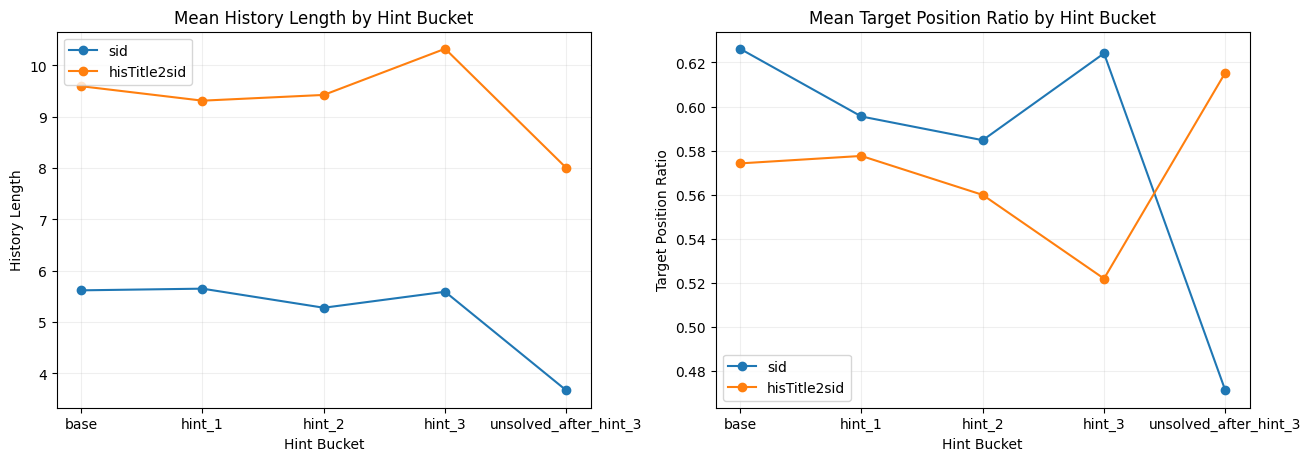

In [19]:
raw_train_row_meta = build_grec_train_row_meta(inter_payload, history_max=HISTORY_MAX)
task_sequence_df = build_task_sequence_meta(raw_train_row_meta, index_payload, items_payload)

sample_df = sample_df.merge(task_sequence_df, on=['task', 'source_index'], how='left')

sequence_summary = (
    sample_df[sample_df['task'].isin(['task1_sid_sft', 'task4_hisTitle2sid'])]
    .groupby(['task_label', 'hint_bucket'], observed=False)
    .agg(
        sample_count=('sample_id', 'size'),
        mean_history_len=('seq_history_len', 'mean'),
        mean_train_seq_len=('seq_train_seq_len', 'mean'),
        mean_target_pos_ratio=('seq_target_pos_ratio', 'mean'),
        repeat_last_item_rate=('seq_target_repeats_last_item', 'mean'),
    )
    .reset_index()
)
display(format_percent_columns(sequence_summary, ['mean_target_pos_ratio', 'repeat_last_item_rate']))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), constrained_layout=True)
plot_df = sequence_summary[sequence_summary['task_label'].isin(['sid', 'hisTitle2sid'])]
for task_label in ['sid', 'hisTitle2sid']:
    task_frame = plot_df[plot_df['task_label'] == task_label]
    axes[0].plot(task_frame['hint_bucket'].astype(str), task_frame['mean_history_len'], marker='o', label=task_label)
    axes[1].plot(task_frame['hint_bucket'].astype(str), task_frame['mean_target_pos_ratio'], marker='o', label=task_label)

axes[0].set_title('Mean History Length by Hint Bucket')
axes[0].set_xlabel('Hint Bucket')
axes[0].set_ylabel('History Length')
axes[1].set_title('Mean Target Position Ratio by Hint Bucket')
axes[1].set_xlabel('Hint Bucket')
axes[1].set_ylabel('Target Position Ratio')
for axis in axes:
    axis.grid(alpha=0.2)
    axis.legend()
plt.show()

## Export

为了减少同步文件数量，只导出一张样本级综合表，后续筛选 deep-hint / residual branch 可以直接从这张表继续做。

In [20]:
EXPORT_DIR.mkdir(parents=True, exist_ok=True)
export_columns = [
    'sample_id',
    'source_index',
    'task',
    'task_label',
    'ground_truth',
    'hint_bucket',
    'base_hit',
    'first_hit_depth',
    'effective_hint_depth',
    'final_unsolved',
    'required_sid_token',
    'required_sid_parent_prefix',
    'required_train_token_count',
    'required_train_token_share',
    'required_task_token_share',
    'required_task_parent_child_share',
    'required_tree_subtree_size',
    'required_tree_child_share',
    'required_tree_child_rank',
    'required_tree_sibling_count',
    'required_tree_parent_entropy',
    'required_tree_parent_gini',
    'required_tree_parent_max_child_share',
    'seq_user_id',
    'seq_train_seq_len',
    'seq_history_len',
    'seq_target_pos_in_train',
    'seq_target_pos_ratio',
    'seq_target_from_end',
    'seq_target_repeats_last_item',
]
export_frame = sample_df[export_columns].copy()
export_path = EXPORT_DIR / f'instruments_grec_beam{FOCUS_BEAM_SIZE}_hint_difficulty_table.csv'
export_frame.to_csv(export_path, index=False)
print(f'Combined sample-level table exported to: {export_path}')
display(export_frame.head(12))

/mnt/dolphinfs/hdd_pool/docker/user/hadoop-hmart-poistar/fanghaotian/conda/envs/grec/lib/python3.10/site-packages/pandas/core/indexes/base.py:7834: RuntimeWarning: invalid value encountered in cast
  values = values.astype(str)
/mnt/dolphinfs/hdd_pool/docker/user/hadoop-hmart-poistar/fanghaotian/conda/envs/grec/lib/python3.10/site-packages/pandas/core/indexes/base.py:7834: RuntimeWarning: invalid value encountered in cast
  values = values.astype(str)
/mnt/dolphinfs/hdd_pool/docker/user/hadoop-hmart-poistar/fanghaotian/conda/envs/grec/lib/python3.10/site-packages/pandas/core/indexes/base.py:7834: RuntimeWarning: invalid value encountered in cast
  values = values.astype(str)
/mnt/dolphinfs/hdd_pool/docker/user/hadoop-hmart-poistar/fanghaotian/conda/envs/grec/lib/python3.10/site-packages/pandas/core/indexes/base.py:7834: RuntimeWarning: invalid value encountered in cast
  values = values.astype(str)
/mnt/dolphinfs/hdd_pool/docker/user/hadoop-hmart-poistar/fanghaotian/conda/envs/grec/lib

Combined sample-level table exported to: /mnt/dolphinfs/hdd_pool/docker/user/hadoop-hmart-poistar/fanghaotian/GenRec/output/jupyter-notebook/genrec-hint-cascade-artifacts/instruments_grec_beam16_hint_difficulty_table.csv


/mnt/dolphinfs/hdd_pool/docker/user/hadoop-hmart-poistar/fanghaotian/conda/envs/grec/lib/python3.10/site-packages/pandas/core/indexes/base.py:7834: RuntimeWarning: invalid value encountered in cast
  values = values.astype(str)
/mnt/dolphinfs/hdd_pool/docker/user/hadoop-hmart-poistar/fanghaotian/conda/envs/grec/lib/python3.10/site-packages/pandas/core/indexes/base.py:7834: RuntimeWarning: invalid value encountered in cast
  values = values.astype(str)
/mnt/dolphinfs/hdd_pool/docker/user/hadoop-hmart-poistar/fanghaotian/conda/envs/grec/lib/python3.10/site-packages/pandas/core/indexes/base.py:7834: RuntimeWarning: invalid value encountered in cast
  values = values.astype(str)


,sample_id,source_index,task,task_label,ground_truth,hint_bucket,base_hit,first_hit_depth,effective_hint_depth,final_unsolved,required_sid_token,required_sid_parent_prefix,required_train_token_count,required_train_token_share,required_task_token_share,required_task_parent_child_share,required_tree_subtree_size,required_tree_child_share,required_tree_child_rank,required_tree_sibling_count,required_tree_parent_entropy,required_tree_parent_gini,required_tree_parent_max_child_share,seq_user_id,seq_train_seq_len,seq_history_len,seq_target_pos_in_train,seq_target_pos_ratio,seq_target_from_end,seq_target_repeats_last_item
0,0,79786,task1_sid_sft,sid,<a_194><b_18><c_196><d_16>,base,True,0.0,0,False,None,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15333,9.0,3.0,3.0,0.375000,6.0,0.0
1,1,53391,task1_sid_sft,sid,<a_125><b_122><c_78><d_50>,hint_2,False,2.0,2,False,<b_122>,<a_125>,567.0,0.005327,0.005360,0.022829,4.0,0.018182,19.0,54.0,0.872396,0.954380,0.113636,8676,4.0,1.0,1.0,0.333333,3.0,0.0
2,2,68707,task1_sid_sft,sid,<a_194><b_134><c_104><d_0>,hint_2,False,2.0,2,False,<b_134>,<a_194>,767.0,0.007206,0.007127,0.003676,4.0,0.012232,25.0,90.0,0.901303,0.974909,0.070336,12213,3.0,1.0,1.0,0.500000,2.0,0.0
3,4,44182,task1_sid_sft,sid,<a_77><b_171><c_238><d_92>,hint_1,False,1.0,1,False,<a_77>,ROOT,3798.0,0.035682,0.038073,0.038073,107.0,0.017120,25.0,41.0,0.931237,0.965282,0.061600,6873,7.0,1.0,1.0,0.166667,6.0,0.0
4,5,80894,task1_sid_sft,sid,<a_199><b_156><c_53><d_207>,hint_1,False,1.0,1,False,<a_199>,ROOT,2547.0,0.023929,0.023960,0.023960,129.0,0.020640,23.0,41.0,0.931237,0.965282,0.061600,15685,7.0,6.0,6.0,1.000000,1.0,0.0
5,6,31936,task1_sid_sft,sid,<a_19><b_157><c_212><d_87>,hint_2,False,2.0,2,False,<b_157>,<a_19>,444.0,0.004171,0.004099,0.030806,10.0,0.040984,4.0,86.0,0.904738,0.973562,0.073770,4669,10.0,5.0,5.0,0.555556,5.0,0.0
6,7,45411,task1_sid_sft,sid,<a_150><b_68><c_242><d_104>,hint_1,False,1.0,1,False,<a_150>,ROOT,2618.0,0.024596,0.023937,0.023937,187.0,0.029920,17.0,41.0,0.931237,0.965282,0.061600,7069,9.0,4.0,4.0,0.500000,5.0,0.0
7,8,5700,task1_sid_sft,sid,<a_125><b_156><c_88><d_97>,hint_2,False,2.0,2,False,<b_156>,<a_125>,2734.0,0.025686,0.027706,0.013363,8.0,0.036364,6.0,54.0,0.872396,0.954380,0.113636,726,13.0,9.0,9.0,0.750000,4.0,0.0
8,9,46733,task1_sid_sft,sid,<a_234><b_63><c_195><d_144>,hint_1,False,1.0,1,False,<a_234>,ROOT,2301.0,0.021618,0.021687,0.021687,161.0,0.025760,22.0,41.0,0.931237,0.965282,0.061600,7319,9.0,6.0,6.0,0.750000,3.0,0.0
9,10,5084,task1_sid_sft,sid,<a_59><b_94><c_178><d_215>,hint_2,False,2.0,2,False,<b_94>,<a_59>,439.0,0.004124,0.004029,0.014263,6.0,0.026201,11.0,75.0,0.934769,0.978052,0.052402,646,13.0,10.0,10.0,0.833333,3.0,0.0


In [21]:
def build_narrative(sample_frame: pd.DataFrame, overview_frame: pd.DataFrame) -> list[str]:
    lines = ['## 自动摘要']

    main_tasks = overview_frame[overview_frame['task_label'].isin(['sid', 'hisTitle2sid'])].copy()
    if len(main_tasks) == 2:
        harder = main_tasks.sort_values('need_hint_rate', ascending=False).iloc[0]
        easier = main_tasks.sort_values('need_hint_rate', ascending=True).iloc[0]
        lines.append(
            f"- 在 `beam={FOCUS_BEAM_SIZE}` 下，**{harder['task_label']}** 比 **{easier['task_label']}** 更依赖 hint："
            f"need-hint rate **{harder['need_hint_rate']:.2%}** vs **{easier['need_hint_rate']:.2%}**，"
            f"hint>=2 rate **{harder['hint_ge_2_rate']:.2%}** vs **{easier['hint_ge_2_rate']:.2%}**。"
        )

    hinted_only = sample_frame[sample_frame['effective_hint_depth'].between(1, MAX_HINT_DEPTH)].copy()
    for task_label in ['sid', 'hisTitle2sid']:
        task_frame = hinted_only[hinted_only['task_label'] == task_label]
        if task_frame.empty:
            continue
        lines.append(
            f"- `{task_label}` 的 required hint token 平均全局频次是 **{task_frame['required_train_token_count'].mean():.2f}**，"
            f"同 parent 条件占比平均是 **{task_frame['required_task_parent_child_share'].mean():.2%}**。"
        )
        lines.append(
            f"- `{task_label}` 的 required subtree 平均大小是 **{task_frame['required_tree_subtree_size'].mean():.2f}**，"
            f"parent max-child-share 平均是 **{task_frame['required_tree_parent_max_child_share'].mean():.2%}**。"
        )

    unsolved_bucket = f'unsolved_after_hint_{MAX_HINT_DEPTH}'
    unsolved_frame = sample_frame[sample_frame['hint_bucket'].astype(str) == unsolved_bucket]
    if not unsolved_frame.empty:
        lines.append(f"- 最终 residual 样本数是 **{len(unsolved_frame)}**，task 分布为 `{unsolved_frame['task_label'].value_counts().to_dict()}`。")

    return lines


display(Markdown('\n'.join(build_narrative(sample_df, sample_overview))))

/mnt/dolphinfs/hdd_pool/docker/user/hadoop-hmart-poistar/fanghaotian/conda/envs/grec/lib/python3.10/site-packages/pandas/core/arrays/categorical.py:595: RuntimeWarning: invalid value encountered in cast
  np.array(self.categories._na_value).astype(dtype)


## 自动摘要
- 在 `beam=16` 下，**hisTitle2sid** 比 **sid** 更依赖 hint：need-hint rate **91.31%** vs **71.75%**，hint>=2 rate **61.24%** vs **32.70%**。
- `sid` 的 required hint token 平均全局频次是 **2288.09**，同 parent 条件占比平均是 **3.36%**。
- `sid` 的 required subtree 平均大小是 **107.58**，parent max-child-share 平均是 **7.11%**。
- `hisTitle2sid` 的 required hint token 平均全局频次是 **1906.09**，同 parent 条件占比平均是 **4.55%**。
- `hisTitle2sid` 的 required subtree 平均大小是 **65.59**，parent max-child-share 平均是 **7.66%**。
- 最终 residual 样本数是 **11**，task 分布为 `{'sid': 6, 'title_desc2sid': 4, 'hisTitle2sid': 1}`。